   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 81.6 MB/s eta 0:00:00
Loading Project Gutenberg corpus...

Available books:
['austen-emma.txt', 'austen-persuasion.txt', 'austen-sense.txt', 'bible-kjv.txt', 'blake-poems.txt', 'bryant-stories.txt', 'burgess-busterbrown.txt', 'carroll-alice.txt', 'chesterton-ball.txt', 'chesterton-brown.txt', 'chesterton-thursday.txt', 'edgeworth-parents.txt', 'melville-moby_dick.txt', 'milton-paradise.txt', 'shakespeare-caesar.txt', 'shakespeare-hamlet.txt', 'shakespeare-macbeth.txt', 'whitman-leaves.txt']

Corpus loaded successfully!
Characters in corpus: 11793336

Preprocessing text...
Original words: 2136080
Clean words: 1025356

First 30 processed words:
['emma', 'jane', 'austen', 'volume', 'chapter', 'emma', 'woodhouse', 'handsome', 'clever', 'rich', 'comfortable', 'home', 'happy', 'disposition', 'seemed', 'unite', 'best', 'blessings', 'existence', 'lived', 'nearly', 'twenty', 'one', 'years', 'world', 'little', 'distress', 'vex', 'youngest', 

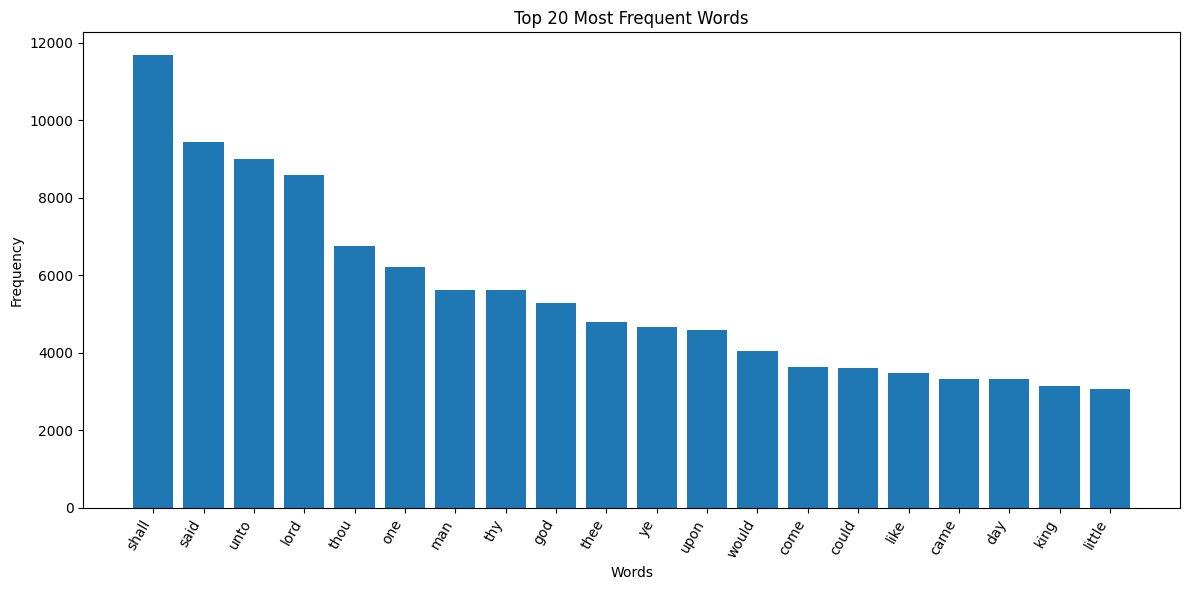


Building Bigram Model...
Bigram model created!
Building Trigram Model...
Trigram model created!

AUTOCOMPLETE RESULTS - 10 PREFIXES

Prefix: said the
Bigram Top 3: []
Trigram Top 3: []

Prefix: one of
Bigram Top 3: []
Trigram Top 3: []

Prefix: in the
Bigram Top 3: []
Trigram Top 3: []

Prefix: it was
Bigram Top 3: []
Trigram Top 3: []

Prefix: there was
Bigram Top 3: []
Trigram Top 3: []

Prefix: as the
Bigram Top 3: []
Trigram Top 3: []

Prefix: to the
Bigram Top 3: []
Trigram Top 3: []

Prefix: with the
Bigram Top 3: []
Trigram Top 3: []

Prefix: for the
Bigram Top 3: []
Trigram Top 3: []

Prefix: from the
Bigram Top 3: []
Trigram Top 3: []


,Prefix,Bigram Top 3,Trigram Top 3
0,said the,,
1,one of,,
2,in the,,
3,it was,,
4,there was,,
5,as the,,
6,to the,,
7,with the,,
8,for the,,
9,from the,,



AUTOCOMPLETE PERFORMANCE
Bigram Precision@3: 0.0763
Bigram Recall@3: 0.229
Bigram Top-1 Accuracy: 0.122

Trigram Precision@3: 0.3147
Trigram Recall@3: 0.944
Trigram Top-1 Accuracy: 0.886

AUTOCORRECT

AUTOCORRECT COMPARISON


,Misspelled Word,Correct Word,SpellChecker,Custom Levenshtein
0,acheive,achieve,achieve,active
1,accomodate,accommodate,accommodate,accommodate
2,adress,address,dress,dress
3,becuase,because,because,became
4,beleive,believe,believe,believe
5,calender,calendar,calender,slender
6,definately,definitely,definitely,infinitely
7,enviroment,environment,environment,engagement
8,existance,existence,existence,existence
9,freind,friend,friend,friend



AUTOCORRECT ACCURACY
SpellChecker Accuracy: 0.9
Custom Levenshtein Accuracy: 0.6

AUTOCORRECT PRECISION AND RECALL
SpellChecker Precision: 0.9
SpellChecker Recall: 0.9

Custom Levenshtein Precision: 0.6
Custom Levenshtein Recall: 0.6


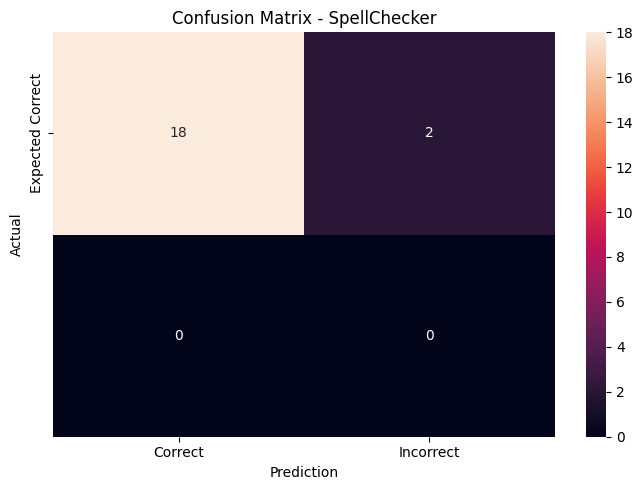

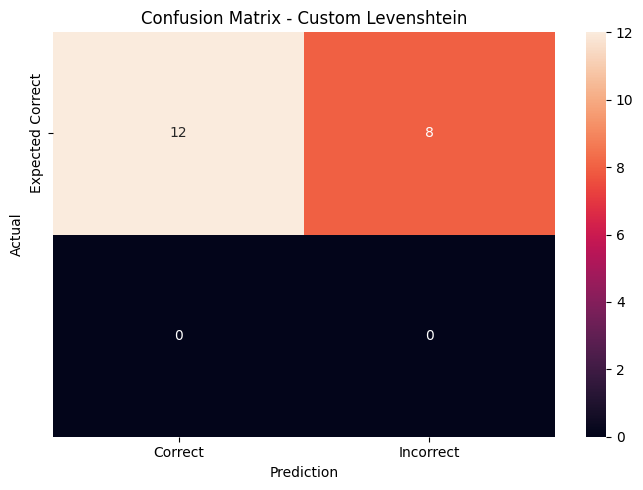


AUTOCORRECT ALGORITHM COMPARISON


,Algorithm,Accuracy,Precision,Recall
0,SpellChecker,0.9,0.9,0.9
1,Custom Levenshtein,0.6,0.6,0.6


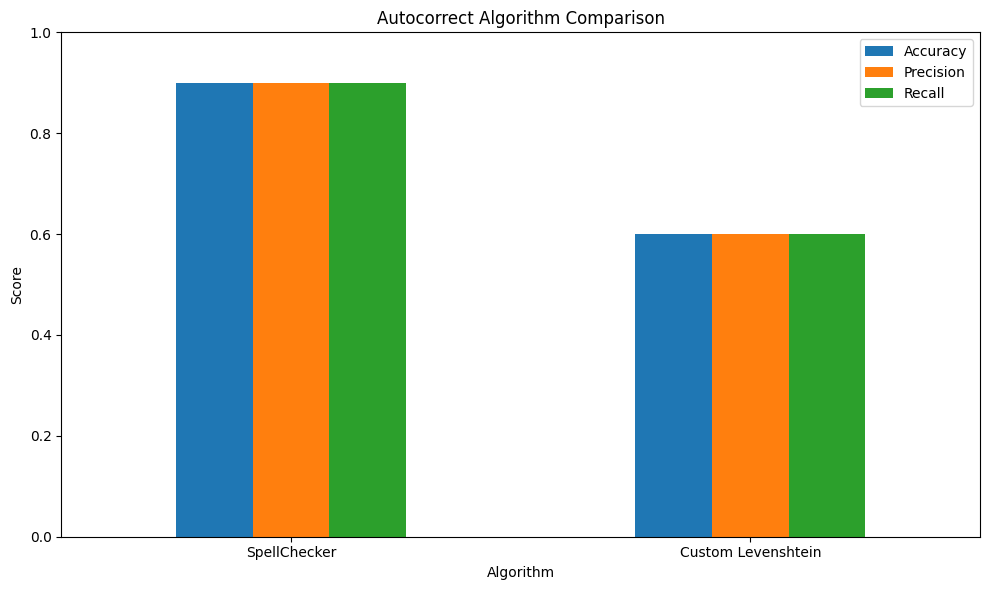


TASK 5 FINAL SUMMARY
Best Autocorrect Algorithm: SpellChecker
Best Accuracy: 0.9

Autocomplete Bigram Precision@3: 0.0763
Autocomplete Bigram Recall@3: 0.229
Autocomplete Trigram Precision@3: 0.3147
Autocomplete Trigram Recall@3: 0.944

LIMITATIONS

1. The autocomplete system is based on frequency-based
   n-gram models and does not deeply understand context.

2. Bigram and trigram models require sufficient training
   data for reliable predictions.

3. Rare words may receive poor predictions.

4. The custom Levenshtein approach can be computationally
   expensive because it compares a misspelled word with
   many dictionary words.

5. Real production systems such as Google Keyboard use
   much larger datasets, contextual language models,
   personalization and neural network based techniques.

6. The current system does not fully understand sarcasm,
   meaning, sentence context or user intent.


TASK 5 COMPLETED SUCCESSFULLY!


In [ ]:
# ============================================================
# OASIS INFOBYTE - DATA ANALYTICS TASK 5
# AUTOCOMPLETE AND AUTOCORRECT DATA ANALYTICS
# ============================================================

# ============================================================
# 1. INSTALL REQUIRED LIBRARIES
# ============================================================

!pip -q install pyspellchecker textdistance


# ============================================================
# 2. IMPORT LIBRARIES
# ============================================================

import re
import math
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import nltk

nltk.download("gutenberg", quiet=True)
nltk.download("punkt", quiet=True)
nltk.download("stopwords", quiet=True)

from nltk.corpus import gutenberg
from nltk.corpus import stopwords

from collections import Counter, defaultdict

from spellchecker import SpellChecker

from sklearn.metrics import confusion_matrix


# ============================================================
# 3. LOAD LARGE TEXT CORPUS
# ============================================================

print("Loading Project Gutenberg corpus...")

books = gutenberg.fileids()

print("\nAvailable books:")
print(books)

# Combine multiple Gutenberg books
raw_text = ""

for book in books:
    raw_text += " " + gutenberg.raw(book)

print("\nCorpus loaded successfully!")
print("Characters in corpus:", len(raw_text))


# ============================================================
# 4. TEXT PREPROCESSING
# ============================================================

print("\nPreprocessing text...")

text = raw_text.lower()

# Remove punctuation and numbers
text = re.sub(
    r"[^a-z\s]",
    " ",
    text
)

# Remove extra spaces
text = re.sub(
    r"\s+",
    " ",
    text
).strip()

# Tokenize
words = text.split()

# Stopwords
stop_words = set(
    stopwords.words("english")
)

# Remove stopwords
clean_words = [
    word
    for word in words
    if word not in stop_words
    and len(word) > 1
]

print("Original words:", len(words))
print("Clean words:", len(clean_words))

print("\nFirst 30 processed words:")
print(clean_words[:30])


# ============================================================
# 5. WORD FREQUENCY
# ============================================================

word_frequency = Counter(clean_words)

print("\nMost frequent words:")

for word, count in word_frequency.most_common(20):
    print(word, ":", count)


# ============================================================
# 6. TOP 20 WORDS VISUALIZATION
# ============================================================

top20 = word_frequency.most_common(20)

top_words = [
    x[0] for x in top20
]

top_counts = [
    x[1] for x in top20
]

plt.figure(figsize=(12,6))

plt.bar(
    top_words,
    top_counts
)

plt.title(
    "Top 20 Most Frequent Words"
)

plt.xlabel("Words")
plt.ylabel("Frequency")

plt.xticks(
    rotation=60,
    ha="right"
)

plt.tight_layout()
plt.show()


# ============================================================
# 7. BUILD BIGRAM MODEL
# ============================================================

print("\nBuilding Bigram Model...")

bigram_counts = defaultdict(Counter)

for i in range(len(clean_words) - 1):

    first_word = clean_words[i]
    next_word = clean_words[i + 1]

    bigram_counts[first_word][next_word] += 1

print("Bigram model created!")


# ============================================================
# 8. BUILD TRIGRAM MODEL
# ============================================================

print("Building Trigram Model...")

trigram_counts = defaultdict(Counter)

for i in range(len(clean_words) - 2):

    first_word = clean_words[i]
    second_word = clean_words[i + 1]
    next_word = clean_words[i + 2]

    prefix = (
        first_word,
        second_word
    )

    trigram_counts[prefix][next_word] += 1

print("Trigram model created!")


# ============================================================
# 9. AUTOCOMPLETE FUNCTION - BIGRAM
# ============================================================

def bigram_autocomplete(prefix, top_n=3):

    prefix_words = prefix.lower().split()

    if len(prefix_words) == 0:
        return []

    last_word = prefix_words[-1]

    if last_word not in bigram_counts:
        return []

    predictions = bigram_counts[
        last_word
    ].most_common(top_n)

    return [
        word for word, count in predictions
    ]


# ============================================================
# 10. AUTOCOMPLETE FUNCTION - TRIGRAM
# ============================================================

def trigram_autocomplete(prefix, top_n=3):

    prefix_words = prefix.lower().split()

    if len(prefix_words) < 2:
        return []

    last_two_words = (
        prefix_words[-2],
        prefix_words[-1]
    )

    if last_two_words not in trigram_counts:
        return []

    predictions = trigram_counts[
        last_two_words
    ].most_common(top_n)

    return [
        word for word, count in predictions
    ]


# ============================================================
# 11. TEST AUTOCOMPLETE ON 10 PREFIXES
# ============================================================

test_prefixes = [
    "said the",
    "one of",
    "in the",
    "it was",
    "there was",
    "as the",
    "to the",
    "with the",
    "for the",
    "from the"
]

print("\n================================================")
print("AUTOCOMPLETE RESULTS - 10 PREFIXES")
print("================================================")

autocomplete_results = []

for prefix in test_prefixes:

    bigram_result = bigram_autocomplete(
        prefix,
        3
    )

    trigram_result = trigram_autocomplete(
        prefix,
        3
    )

    print("\nPrefix:", prefix)

    print(
        "Bigram Top 3:",
        bigram_result
    )

    print(
        "Trigram Top 3:",
        trigram_result
    )

    autocomplete_results.append({
        "Prefix": prefix,
        "Bigram Top 3": ", ".join(
            bigram_result
        ),
        "Trigram Top 3": ", ".join(
            trigram_result
        )
    })


autocomplete_results_df = pd.DataFrame(
    autocomplete_results
)

display(
    autocomplete_results_df
)


# ============================================================
# 12. AUTOCOMPLETE EVALUATION DATA
# ============================================================

# Use real consecutive word sequences from the corpus
# to evaluate whether the true next word appears in top 3.

evaluation_size = 1000

bigram_correct = 0
trigram_correct = 0

bigram_top3_total = 0
trigram_top3_total = 0

bigram_top1_correct = 0
trigram_top1_correct = 0

evaluation_records = []


for i in range(
    1,
    min(
        evaluation_size + 1,
        len(clean_words) - 1
    )
):

    prefix = clean_words[i - 1]
    actual_next = clean_words[i]

    bigram_predictions = bigram_autocomplete(
        prefix,
        3
    )

    if actual_next in bigram_predictions:
        bigram_correct += 1

    bigram_top3_total += 1

    if (
        len(bigram_predictions) > 0
        and bigram_predictions[0] == actual_next
    ):
        bigram_top1_correct += 1


# Trigram evaluation
for i in range(
    2,
    min(
        evaluation_size + 2,
        len(clean_words)
    )
):

    prefix = (
        clean_words[i - 2]
        + " "
        + clean_words[i - 1]
    )

    actual_next = clean_words[i]

    trigram_predictions = trigram_autocomplete(
        prefix,
        3
    )

    if actual_next in trigram_predictions:
        trigram_correct += 1

    trigram_top3_total += 1

    if (
        len(trigram_predictions) > 0
        and trigram_predictions[0] == actual_next
    ):
        trigram_top1_correct += 1


# ============================================================
# 13. AUTOCOMPLETE PRECISION AND RECALL
# ============================================================

# Precision@3 = correct predictions / total predictions
# Recall@3 = correct predictions / total actual next words

bigram_precision = (
    bigram_correct /
    (bigram_top3_total * 3)
)

bigram_recall = (
    bigram_correct /
    bigram_top3_total
)

trigram_precision = (
    trigram_correct /
    (trigram_top3_total * 3)
)

trigram_recall = (
    trigram_correct /
    trigram_top3_total
)

bigram_top1_accuracy = (
    bigram_top1_correct /
    bigram_top3_total
)

trigram_top1_accuracy = (
    trigram_top1_correct /
    trigram_top3_total
)


print("\n================================================")
print("AUTOCOMPLETE PERFORMANCE")
print("================================================")

print(
    "Bigram Precision@3:",
    round(bigram_precision, 4)
)

print(
    "Bigram Recall@3:",
    round(bigram_recall, 4)
)

print(
    "Bigram Top-1 Accuracy:",
    round(bigram_top1_accuracy, 4)
)

print(
    "\nTrigram Precision@3:",
    round(trigram_precision, 4)
)

print(
    "Trigram Recall@3:",
    round(trigram_recall, 4)
)

print(
    "Trigram Top-1 Accuracy:",
    round(trigram_top1_accuracy, 4)
)


# ============================================================
# 14. AUTOCORRECT - SPELLCHECKER
# ============================================================

print("\n================================================")
print("AUTOCORRECT")
print("================================================")

spell = SpellChecker(
    language="en"
)


# ============================================================
# 15. 20 DELIBERATELY MISSPELLED WORDS
# ============================================================

misspelled_words = [
    "acheive",
    "accomodate",
    "adress",
    "becuase",
    "beleive",
    "calender",
    "definately",
    "enviroment",
    "existance",
    "freind",
    "goverment",
    "grammer",
    "independant",
    "knowlege",
    "occured",
    "recieve",
    "seperate",
    "sucessful",
    "tomorow",
    "wierd"
]

correct_words = [
    "achieve",
    "accommodate",
    "address",
    "because",
    "believe",
    "calendar",
    "definitely",
    "environment",
    "existence",
    "friend",
    "government",
    "grammar",
    "independent",
    "knowledge",
    "occurred",
    "receive",
    "separate",
    "successful",
    "tomorrow",
    "weird"
]


# ============================================================
# 16. SPELLCHECKER CORRECTIONS
# ============================================================

spellchecker_results = []

for word in misspelled_words:

    correction = spell.correction(word)

    spellchecker_results.append(
        correction
    )


# ============================================================
# 17. CUSTOM LEVENSHTEIN AUTOCORRECT
# ============================================================

def levenshtein_distance(
    word1,
    word2
):

    m = len(word1)
    n = len(word2)

    dp = [
        [0] * (n + 1)
        for _ in range(m + 1)
    ]

    for i in range(m + 1):
        dp[i][0] = i

    for j in range(n + 1):
        dp[0][j] = j

    for i in range(1, m + 1):

        for j in range(1, n + 1):

            cost = (
                0
                if word1[i - 1] ==
                   word2[j - 1]
                else 1
            )

            dp[i][j] = min(
                dp[i - 1][j] + 1,
                dp[i][j - 1] + 1,
                dp[i - 1][j - 1] + cost
            )

    return dp[m][n]


# Use frequent corpus words as dictionary
dictionary_words = [
    word
    for word, count
    in word_frequency.most_common(10000)
]


def custom_autocorrect(
    misspelled_word
):

    candidates = []

    for word in dictionary_words:

        # Small length filter
        if abs(
            len(word)
            - len(misspelled_word)
        ) > 3:
            continue

        distance = levenshtein_distance(
            misspelled_word,
            word
        )

        candidates.append(
            (distance, -word_frequency[word], word)
        )

    if not candidates:
        return misspelled_word

    candidates.sort()

    return candidates[0][2]


custom_results = []

for word in misspelled_words:

    correction = custom_autocorrect(
        word
    )

    custom_results.append(
        correction
    )


# ============================================================
# 18. AUTOCORRECT COMPARISON TABLE
# ============================================================

autocorrect_results = pd.DataFrame({

    "Misspelled Word":
        misspelled_words,

    "Correct Word":
        correct_words,

    "SpellChecker":
        spellchecker_results,

    "Custom Levenshtein":
        custom_results
})

print("\n================================================")
print("AUTOCORRECT COMPARISON")
print("================================================")

display(
    autocorrect_results
)


# ============================================================
# 19. AUTOCORRECT ACCURACY
# ============================================================

spellchecker_correct = sum(
    predicted == actual
    for predicted, actual
    in zip(
        spellchecker_results,
        correct_words
    )
)

custom_correct = sum(
    predicted == actual
    for predicted, actual
    in zip(
        custom_results,
        correct_words
    )
)

total_words = len(
    correct_words
)

spellchecker_accuracy = (
    spellchecker_correct /
    total_words
)

custom_accuracy = (
    custom_correct /
    total_words
)


print("\n================================================")
print("AUTOCORRECT ACCURACY")
print("================================================")

print(
    "SpellChecker Accuracy:",
    round(spellchecker_accuracy, 4)
)

print(
    "Custom Levenshtein Accuracy:",
    round(custom_accuracy, 4)
)


# ============================================================
# 20. AUTOCORRECT PRECISION AND RECALL
# ============================================================

def correction_metrics(
    predicted,
    actual
):

    tp = sum(
        p == a
        for p, a in zip(
            predicted,
            actual
        )
    )

    fp = sum(
        p != a
        for p, a in zip(
            predicted,
            actual
        )
    )

    fn = fp

    precision = (
        tp / (tp + fp)
        if (tp + fp) > 0
        else 0
    )

    recall = (
        tp / (tp + fn)
        if (tp + fn) > 0
        else 0
    )

    return precision, recall


spell_precision, spell_recall = (
    correction_metrics(
        spellchecker_results,
        correct_words
    )
)

custom_precision, custom_recall = (
    correction_metrics(
        custom_results,
        correct_words
    )
)


print("\n================================================")
print("AUTOCORRECT PRECISION AND RECALL")
print("================================================")

print(
    "SpellChecker Precision:",
    round(spell_precision, 4)
)

print(
    "SpellChecker Recall:",
    round(spell_recall, 4)
)

print(
    "\nCustom Levenshtein Precision:",
    round(custom_precision, 4)
)

print(
    "Custom Levenshtein Recall:",
    round(custom_recall, 4)
)


# ============================================================
# 21. AUTOCORRECT CONFUSION MATRIX
# ============================================================

spell_correct_flags = [
    1 if p == a else 0
    for p, a in zip(
        spellchecker_results,
        correct_words
    )
]

custom_correct_flags = [
    1 if p == a else 0
    for p, a in zip(
        custom_results,
        correct_words
    )
]

# 1 = Correctly corrected
# 0 = Incorrectly corrected

spell_cm = confusion_matrix(
    [1] * total_words,
    spell_correct_flags,
    labels=[1,0]
)

custom_cm = confusion_matrix(
    [1] * total_words,
    custom_correct_flags,
    labels=[1,0]
)


plt.figure(figsize=(7,5))

sns.heatmap(
    spell_cm,
    annot=True,
    fmt="d",
    xticklabels=[
        "Correct",
        "Incorrect"
    ],
    yticklabels=[
        "Expected Correct"
    ]
)

plt.title(
    "Confusion Matrix - SpellChecker"
)

plt.xlabel("Prediction")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()


plt.figure(figsize=(7,5))

sns.heatmap(
    custom_cm,
    annot=True,
    fmt="d",
    xticklabels=[
        "Correct",
        "Incorrect"
    ],
    yticklabels=[
        "Expected Correct"
    ]
)

plt.title(
    "Confusion Matrix - Custom Levenshtein"
)

plt.xlabel("Prediction")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()


# ============================================================
# 22. ALGORITHM COMPARISON
# ============================================================

comparison = pd.DataFrame({

    "Algorithm": [
        "SpellChecker",
        "Custom Levenshtein"
    ],

    "Accuracy": [
        spellchecker_accuracy,
        custom_accuracy
    ],

    "Precision": [
        spell_precision,
        custom_precision
    ],

    "Recall": [
        spell_recall,
        custom_recall
    ]
})

print("\n================================================")
print("AUTOCORRECT ALGORITHM COMPARISON")
print("================================================")

display(
    comparison
)


# ============================================================
# 23. COMPARISON GRAPH
# ============================================================

comparison.set_index(
    "Algorithm"
)[
    [
        "Accuracy",
        "Precision",
        "Recall"
    ]
].plot(
    kind="bar",
    figsize=(10,6)
)

plt.title(
    "Autocorrect Algorithm Comparison"
)

plt.ylabel("Score")

plt.ylim(0,1)

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()


# ============================================================
# 24. FINAL SUMMARY
# ============================================================

best_autocorrect = comparison.loc[
    comparison["Accuracy"].idxmax()
]

print("\n================================================")
print("TASK 5 FINAL SUMMARY")
print("================================================")

print(
    "Best Autocorrect Algorithm:",
    best_autocorrect["Algorithm"]
)

print(
    "Best Accuracy:",
    round(
        best_autocorrect["Accuracy"],
        4
    )
)

print(
    "\nAutocomplete Bigram Precision@3:",
    round(bigram_precision,4)
)

print(
    "Autocomplete Bigram Recall@3:",
    round(bigram_recall,4)
)

print(
    "Autocomplete Trigram Precision@3:",
    round(trigram_precision,4)
)

print(
    "Autocomplete Trigram Recall@3:",
    round(trigram_recall,4)
)


# ============================================================
# 25. LIMITATIONS
# ============================================================

print("""
============================================================
LIMITATIONS
============================================================

1. The autocomplete system is based on frequency-based
   n-gram models and does not deeply understand context.

2. Bigram and trigram models require sufficient training
   data for reliable predictions.

3. Rare words may receive poor predictions.

4. The custom Levenshtein approach can be computationally
   expensive because it compares a misspelled word with
   many dictionary words.

5. Real production systems such as Google Keyboard use
   much larger datasets, contextual language models,
   personalization and neural network based techniques.

6. The current system does not fully understand sarcasm,
   meaning, sentence context or user intent.
============================================================
""")


# ============================================================
# 26. SAVE OUTPUT FILES
# ============================================================

autocomplete_results_df.to_csv(
    "autocomplete_results.csv",
    index=False
)

autocorrect_results.to_csv(
    "autocorrect_results.csv",
    index=False
)

comparison.to_csv(
    "autocorrect_model_comparison.csv",
    index=False
)

print("\n================================================")
print("TASK 5 COMPLETED SUCCESSFULLY!")
print("================================================")